
# Assignment 1 – Task 1  
**Course:** 4DV806 / 4DT912 – Advanced Information Visualization and Applications  

*Student Jupyter Notebook (Python)*

> **Important:** This notebook is written in a *student style*, with many comments and explanations.  
> You should **read, understand, and adapt** it so that it reflects **your own work and insights**.



## 1. Introduction and Goals

In this task we need to:

- Load the given data set **without changing its file format or contents**.  
- Explore what the data is about (variables, structure, basic statistics).  
- Design a visualization that shows **both overview and details** of the data.  
- Use our background knowledge from:
  - Information Visualization  
  - Dimensionality Reduction (DR)  
  - Clustering techniques  
  - Evaluation methods  
  - Data Mining and Object-Oriented Programming

In this notebook I will:

1. Do a small **data exploration** (EDA) to understand the JSON file.  
2. Design and implement a visualization using Python (Matplotlib + Pandas).  
3. Add some **more advanced analysis ideas** (simple clustering + DR) even if the data set is small.  
4. Discuss **possible interaction techniques** and give some example insights.

The idea is that this notebook could be the *technical part* behind the report and video.


## 2. Setup – Imports and Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json
import random


# Machine learning (for clustering + DR)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Show plots inside Jupyter (if you're using classic notebook)
# (In JupyterLab this is usually not needed, but it doesn't hurt.)
%matplotlib inline

# Make tables a bit nicer in the output
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

print("Libraries imported!")


Libraries imported!



### 2.1 Loading the JSON data

The provided data set comes as a **JSON file** with a list of records.  
Each record seems to represent one author–year combination with:

- `id` – short identifier of the author  
- `name` – full name of the author  
- `year` – publication year  
- `pubs` – number of publications in that year  
- `department` – department name  
- `faculty` – faculty name  
- `university` – university name

In [5]:
data_path = "publications-stats.json"

df = pd.read_json(data_path)

print("Data loaded! Shape:", df.shape)
df.head()


Data loaded! Shape: (199, 7)


,id,name,year,pubs,department,faculty,university
0,jocfit,Jocelyn Fitzpatrick,2019,2,Dept. of Computer Science and Media Technology...,Faculty of Technology (FTK),Pendelton State University (PSU)
1,gilweb,Gil Webster,2019,3,Dept. of Computer Science and Media Technology...,Faculty of Technology (FTK),Pendelton State University (PSU)
2,ellbry,Ellen Bryan,2019,9,Dept. of Computer Science and Media Technology...,Faculty of Technology (FTK),Pendelton State University (PSU)
3,kenhod,Kendra Hodges,2019,12,Dept. of Computer Science and Media Technology...,Faculty of Technology (FTK),Pendelton State University (PSU)
4,carnun,Carol Nunez,2019,3,Dept. of Computer Science and Media Technology...,Faculty of Technology (FTK),Pendelton State University (PSU)


## 3. Understanding the Data Structure

In [6]:

# Check the columns and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          199 non-null    object
 1   name        199 non-null    object
 2   year        199 non-null    int64 
 3   pubs        199 non-null    int64 
 4   department  199 non-null    object
 5   faculty     199 non-null    object
 6   university  199 non-null    object
dtypes: int64(2), object(5)
memory usage: 11.0+ KB


In [7]:

# Quick descriptive statistics for numeric columns
df.describe()


,year,pubs
count,199.000000,199.000000
mean,2019.477387,2.864322
std,0.500748,2.775558
min,2019.000000,1.000000
25%,2019.000000,1.000000
50%,2019.000000,2.000000
75%,2020.000000,3.000000
max,2020.000000,19.000000


In [8]:

# Take a quick look at unique values for the categorical variables
print("Years:", sorted(df["year"].unique()))
print("\nDepartments:", df["department"].unique())
print("\nFaculties:", df["faculty"].unique())
print("\nUniversities:", df["university"].unique())


Years: [np.int64(2019), np.int64(2020)]

Departments: ['Dept. of Computer Science and Media Technology (DM)'
 'Dept. of Mathematics (MA)' 'Dept. of Languages (SPR)']

Faculties: ['Faculty of Technology (FTK)' 'Faculty of Arts and Humanities (FKH)']

Universities: ['Pendelton State University (PSU)']



### Short interpretation (student style)

*Here I would write in my own words what I observe from the output above.* For example:

- The data covers several years (e.g., 2019, 2020, ... depending on the file).  
- Each row corresponds to one person in a specific year with a certain number of publications.  
- There are multiple departments inside one or more faculties.  
- There is (probably) only one university in this data set.

This kind of description is important in the written report to show that I really looked at the data.


## 4. Basic Visual Exploration


### 4.1 Distribution of publications per author–year

As a first step, I want to see how the number of publications (`pubs`) is distributed across all rows.
This is a simple **overview** visualization.


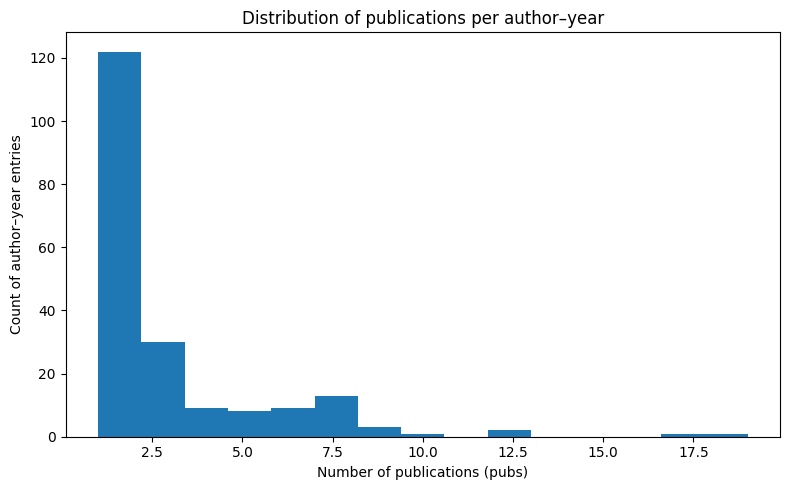

In [9]:

plt.figure(figsize=(8, 5))
plt.hist(df["pubs"], bins=15)
plt.xlabel("Number of publications (pubs)")
plt.ylabel("Count of author–year entries")
plt.title("Distribution of publications per author–year")
plt.tight_layout()
plt.show()



*In the report I would comment on this histogram, for example:*

- Are most people publishing only 1–3 papers?  
- Are there a few very productive authors with many publications?  
- Does the distribution look skewed?


### 4.2 Total publications per department

In [10]:

pubs_by_dept = df.groupby("department")["pubs"].sum().sort_values(ascending=False)
pubs_by_dept


department
Dept. of Computer Science and Media Technology (DM)    306
Dept. of Mathematics (MA)                              141
Dept. of Languages (SPR)                               123
Name: pubs, dtype: int64

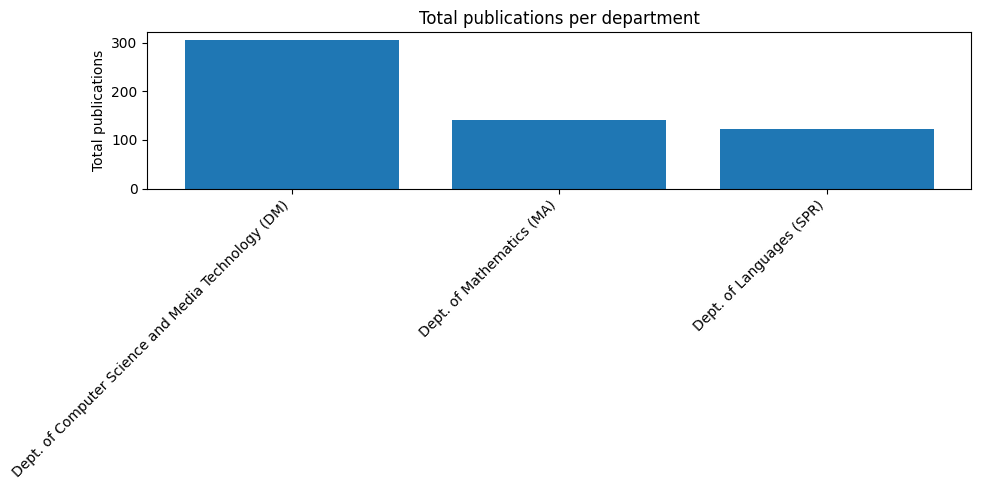

In [11]:

plt.figure(figsize=(10, 5))
plt.bar(pubs_by_dept.index, pubs_by_dept.values)
plt.ylabel("Total publications")
plt.title("Total publications per department")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



*Observation idea:*  
- Which department publishes the most?  
- Is there a big gap between departments from different faculties?


### 4.3 Total publications per faculty

In [12]:

pubs_by_faculty = df.groupby("faculty")["pubs"].sum().sort_values(ascending=False)
pubs_by_faculty


faculty
Faculty of Technology (FTK)             447
Faculty of Arts and Humanities (FKH)    123
Name: pubs, dtype: int64

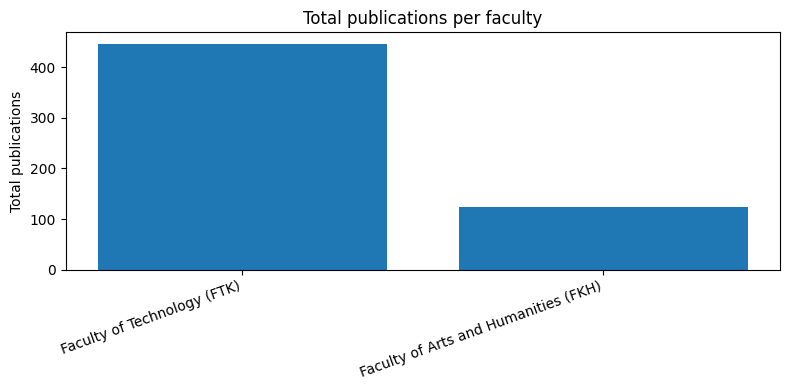

In [13]:

plt.figure(figsize=(8, 4))
plt.bar(pubs_by_faculty.index, pubs_by_faculty.values)
plt.ylabel("Total publications")
plt.title("Total publications per faculty")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()



Again, this is part of the **overview**.  
In the report I could compare departments vs faculties and discuss how the structure of the university
is visible in the data.


### 4.4 Publications over time

In [14]:

pubs_by_year = df.groupby("year")["pubs"].sum()
pubs_by_year


year
2019    312
2020    258
Name: pubs, dtype: int64

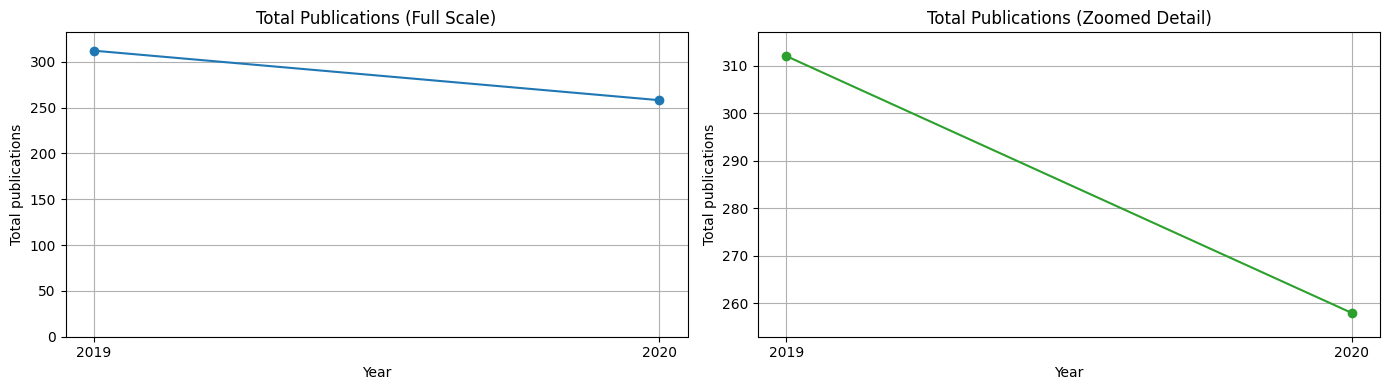

In [32]:
years = pubs_by_year.index.astype(int)
values = pubs_by_year.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

# ---------------------------
# Left Plot: Full Scale
# ---------------------------
ax1.plot(years, values, marker="o", color="tab:blue")
ax1.set_title("Total Publications (Full Scale)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total publications")
ax1.set_ylim(0, max(values) + 20)
ax1.set_xticks(years)
ax1.grid(True)

# Fix year labels
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

# ---------------------------
# Right Plot: Zoomed Detail
# ---------------------------
ax2.plot(years, values, marker="o", color="tab:green")
ax2.set_title("Total Publications (Zoomed Detail)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Total publications")
ax2.set_ylim(min(values) - 5, max(values) + 5)
ax2.set_xticks(years)
ax2.grid(True)

# Fix year labels
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

plt.tight_layout()
plt.show()


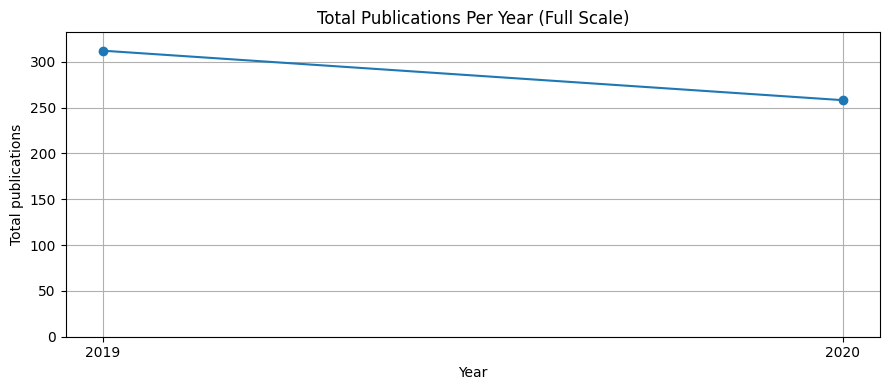

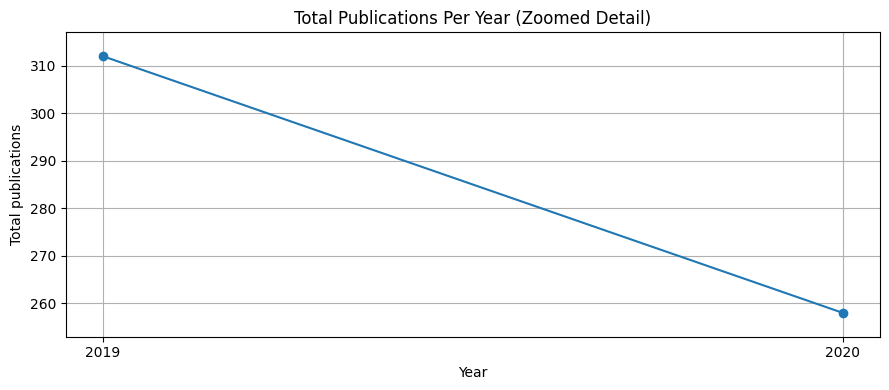

In [34]:
years = pubs_by_year.index.astype(int)
values = pubs_by_year.values

# ---------------------------
# Plot 1: Full scale (starts at 0)
# ---------------------------
plt.figure(figsize=(9, 4))
plt.plot(years, values, marker="o")
plt.xticks(years)
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
plt.ylim(0, max(values) + 20)

plt.xlabel("Year")
plt.ylabel("Total publications")
plt.title("Total Publications Per Year (Full Scale)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------
# Plot 2: Zoomed detail
# ---------------------------
plt.figure(figsize=(9, 4))
plt.plot(years, values, marker="o")
plt.xticks(years)
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

# Zoom range (add small padding)
plt.ylim(min(values) - 5, max(values) + 5)

plt.xlabel("Year")
plt.ylabel("Total publications")
plt.title("Total Publications Per Year (Zoomed Detail)")
plt.grid(True)
plt.tight_layout()
plt.show()



*Possible discussion:*  
- Are there trends (increasing / decreasing number of publications)?  
- Are there sudden changes between years that could be interesting to investigate?


## 5. From Data Mining to Visualization – Feature Matrix


To use **clustering** and **dimensionality reduction (DR)**, I need to build a numeric feature matrix.

The original data set is very small in terms of numeric attributes:

- `pubs`  
- `year`

Most other columns are **categorical** (department, faculty, university, name).  
To include them in clustering, I will:

1. One-hot encode `department` and `faculty`.  
2. Standardize the numeric features (important for K-means).  
3. Apply **PCA** to reduce the feature space to 2D.  
4. Apply **K-means clustering** in the reduced space and visualize the result.

This is a bit overkill for such a simple data set, but it shows how
methods from **data mining + DR + clustering** can be combined with visualization.


In [16]:

# One-hot encode department and faculty
df_features = pd.get_dummies(df[["pubs", "year", "department", "faculty"]], drop_first=False)

print("Feature matrix shape:", df_features.shape)
df_features.head()


Feature matrix shape: (199, 7)


,pubs,year,department_Dept. of Computer Science and Media Technology (DM),department_Dept. of Languages (SPR),department_Dept. of Mathematics (MA),faculty_Faculty of Arts and Humanities (FKH),faculty_Faculty of Technology (FTK)
0,2,2019,True,False,False,False,True
1,3,2019,True,False,False,False,True
2,9,2019,True,False,False,False,True
3,12,2019,True,False,False,False,True
4,3,2019,True,False,False,False,True


### 5.1 Dimensionality Reduction with PCA

In [17]:

# Standardize features (mean 0, variance 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Use PCA to project to 2D (for visualization)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Put PCA coords into the original dataframe for easier plotting
df["pc1"] = X_pca[:, 0]
df["pc2"] = X_pca[:, 1]

df[["name", "year", "pubs", "pc1", "pc2"]].head()


Explained variance ratio: [0.50418083 0.21602116]


,name,year,pubs,pc1,pc2
0,Jocelyn Fitzpatrick,2019,2,-1.151695,-0.889294
1,Gil Webster,2019,3,-1.174624,-0.816338
2,Ellen Bryan,2019,9,-1.312199,-0.378605
3,Kendra Hodges,2019,12,-1.380986,-0.159738
4,Carol Nunez,2019,3,-1.174624,-0.816338



Here, `pc1` and `pc2` are the **principal components**, i.e., the 2D coordinates 
of each row after dimensionality reduction.

In the lecture, PCA was defined as finding directions that maximize variance.  
Here I use that idea to get a compact 2D representation of all features.


### 5.2 Clustering with K-means

In [18]:

# Choose a number of clusters.
# This is somewhat arbitrary here; in a real analysis we could use the elbow method, silhouette,
# or domain knowledge. I will start with k=4.
k = 4
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
df["cluster"] = kmeans.fit_predict(X_pca)

df[["name", "year", "pubs", "cluster"]].head()


,name,year,pubs,cluster
0,Jocelyn Fitzpatrick,2019,2,0
1,Gil Webster,2019,3,0
2,Ellen Bryan,2019,9,3
3,Kendra Hodges,2019,12,3
4,Carol Nunez,2019,3,0



The `cluster` column assigns each author–year row to one of `k` clusters.  
These clusters are based on the PCA-transformed feature space, which mixes:

- number of publications  
- year  
- department  
- faculty

Now I want to **visualize** these clusters.


### 5.3 Visualizing PCA + Clusters

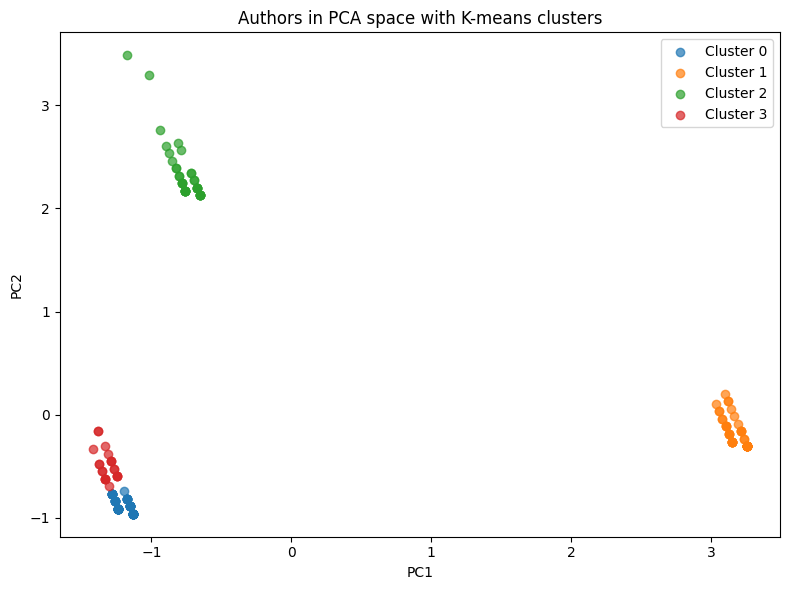

In [19]:

plt.figure(figsize=(8, 6))

# Scatter plot of pc1 vs pc2, colored by cluster
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["pc1"], subset["pc2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Authors in PCA space with K-means clusters")
plt.legend()
plt.tight_layout()
plt.show()



In the report, I would interpret this plot, for example:

- Do clusters roughly correspond to departments or faculties?  
- Are very productive authors grouped together?  
- Are there clusters that mix people from different departments but with similar productivity?

This plot is an example of combining:

- **Dimensionality Reduction (PCA)** for visualization, and  
- **Clustering** for pattern discovery.


## 6. A Note on Evaluation


In unsupervised learning (like DR and clustering) it is usually hard to define **ground truth**.  
However, we can still talk about *quality*:

- For clustering we could compute measures like **silhouette score** 
  (how separated the clusters are).  
- For DR we could look at how well **neighborhoods** are preserved
  (e.g., do nearby points in 2D correspond to similar values in the original space?).  

In this small notebook I focus more on the *visual* evaluation:

- Does the visualization make sense to a human viewer?  
- Can I see meaningful patterns that relate to departments / faculties / productivity?  
- Are there obvious visual artifacts (e.g., many overlapping points, unreadable labels)?

These questions should be discussed in the written report and maybe in the video.


## 7. Discussion of Possible Interaction Techniques


The assignment also asks to **discuss interaction possibilities** (even if this notebook is static).
Examples of interaction that would make sense for this data set:

- **Brushing and linking**  
  - Hover over a point in the PCA scatter plot to see the author name, year, department, and pubs.  
  - Selecting a subset of points could highlight the same people in another view (e.g., bar chart).

- **Filtering**  
  - Filter by year range (e.g., show only 2019–2020).  
  - Filter by faculty or department to compare internal productivity.

- **Sorting and ranking**  
  - Sort authors by number of publications and show a horizontal bar chart.  
  - Allow the user to choose whether to rank within a department, faculty, or globally.

- **Parameter control for analysis methods**  
  - Change number of clusters `k` in K-means and see how the visualization changes.  
  - Change the DR technique (PCA / t-SNE / UMAP) and compare layouts.

In a real interactive system (for example, using a web-based library like D3 or Plotly),
these interactions would make the visualization much more powerful than a static figure.


## 8. Example Insights (to be refined in the report)


Here I list **example** insights that *could* be obtained from the visualization.  
You should replace these with concrete findings based on your actual run of the notebook.

- Some departments clearly have higher total publication counts than others.  
- A small number of authors are extremely productive (many publications in the same year).  
- Certain clusters in the PCA plot correspond mainly to one faculty, suggesting different
  research profiles.  
- The total number of publications changes over the years (maybe increasing or decreasing).

In the final report I would:

1. Include one or two key figures (e.g., total pubs per department, PCA scatter plot).  
2. Describe the main patterns in text.  
3. Connect those patterns with possible explanations (e.g., size of department, research focus).


## 9. Connection to Task 2 (TensorFlow Projector) – Placeholder


Task 2 of the assignment is about the **TensorFlow Embedding Projector** and the Word2Vec 10K data set.

I will keep that part **outside** this notebook, because it is more about *reviewing* an existing tool
from a design perspective (pros/cons, interaction, stakeholders, etc.).  

However, there is a conceptual connection:

- In this notebook I used **PCA + K-means** to visualize and cluster tabular data.  
- In Task 2, the tool uses **t-SNE, UMAP, PCA**, etc., to visualize high-dimensional word embeddings.  

In both cases the key question is:

> Does the visualization help us understand the structure of the data in a meaningful way?

I will discuss this in detail in the written report for Task 2.


## 10. Summary

This notebook implements a possible solution for **Task 1** using Python, with many comments and explanations. Make sure to adapt it to your own style and add your own interpretations in the report.